# Chapter 10: Morphological Image Processing

The term **morphology** refers to the study of the forms and structures. In biology, morphology investigates the form of the animals and plants. In linguistics, morphology investigates how the words are  formed in a language.

In image processing, we use [mathematical morphology](https://en.wikipedia.org/wiki/Mathematical_morphology), which involves techniques  for  processing the shape of the  objects, using set theory.    


Morphological operations, sometimes called, **Minkowsky operations**, are a  set of image processing operations, which  transform the shape of the objects in an image into a “desired” form. For example, we may need to fill up undesired holes  or prune some spurious extensions of an object, such as letters of a scanned document image.   We may want to shrink or enlarge an object in a prescribed shape. These image processing tasks can be accomplished by mathematical morphology.

Loosely speaking, morphological operations are analogous to the convolution operations, where the arithmetic operations are replaced by logical operations. As we slide a mask over the image, instead of using arithmetic operations of multiplying and adding the overlapping pixels, we apply logic operations, such as $AND$, $OR$ or $NOT$ etc. 


In this chapter, first, we define the basics of mathematical morphology. Then, we apply the techniques in mathematical morphology to binary images to reshape the objects. For this purpose, we represent a binary image as a point set. This representation enables us to apply logical operations to binary images. Finally, we extend the binary morphology into gray scale morphology, in which set operations are applicable to gray scale images.



## Mathematical Morphology

The language of mathematical morphology is **set theory**, where images are represented by point sets.

Set theory is a branch of mathematical logic, which studies the formal properties of sets. Loosely speaking, sets  are  defined as the  collections of objects. Although any type of objects can be collected into a set, set theory is applied most often to mathematical objects, such as  numbers, functions, expressions, geometric shapes etc. 

### Representation of Binary  Images as Point Sets

Until now, we have seen several representations of images. For example, a two dimensional gray scale image  image can be represented by
-	a  2-dimensional function,
$$f(x,y): D \rightarrow R, $$

where the domain consists of 2-dimensional coordinates of the image, $(x,y) \in D$ and the range corresponds to the gray scale value, $r\in R$, at a particular pixel coordinate, $(x,y) \in D$,
-	an NxM matrix, where we can apply matrix operations or
-	a two-dimensional array, where we can apply array operations.

**Motivating Question:** How can we represent an image as a point set so that we can apply logical operations?

Let us, first,  represent a binary image by a point set. Then, we  extend this representation to gray level, color and multispectral images. 

Consider a binary image, represented as a matrix;

$$f = \begin{bmatrix}f(0,0) \qquad \quad& ... & f(0,N-1) \\ && \\f(M-1,0) & ... & f(M-1,N-1)\end{bmatrix},$$

where the pixels with the range $f(x,y) =1$ correspond to the object(s) and  $f(x,y) =0$, corresponds to the background of the image. 

An image is represented by a point set, 
$$A = \{(x_i, y_i): \forall f(x_i,y_i) =1\},$$
 
where the elements, $(x_i, y_i)\in Z^2$, represent the integer-valued coordinates of the object pixels, in two dimensional integer grid space, $Z^2$. 

In other words,  a point set $A$, which represents a binary image, consists of the elements corresponding to the pixel coordinates of the object(s). 

**Note:** The above definition of the point set  omits the coordinates of the background pixels. 

**Example:** Represent the following binary image by a point set:
$$f = \begin{bmatrix}0 &0& 0& 0\\0& 0& 0& 0 \\1 &1& 0& 0 \\1 &1&  0& 0 \end{bmatrix}.$$

Assume that the origin, $(0,0)$,  is the upper left corner of the matrix.

**Answer:**   This image has a square object at the lower left corner. It is represented by the following point set:

$$A = \{(2,0), (2,1), (3,0), (3,1)\}.$$

The point set, $A$, which represents the image $f$ consists of 4 elements corresponding to the coordinates of the object pixels, omitting the background pixels. Note that the elements of the point set are in  two-dimensional integer space, $Z^2$.


## Logical Operations 

Logical operators are defined by [George Bool](https://en.wikipedia.org/wiki/George_Boole),  in [Boolean Algebra](https://en.wikipedia.org/wiki/George_Boole), as an alternative to elementary Algebra. The operators, sometimes called the Boolean operators, are the conjunction (AND operation) and disjunction (OR operation) and negation (NOT operation)  applied on two values, namely, TRUE (indicated by 1) and FALSE, indicated by 0.  

Since the pixel brightness values of a binary image is either 0 or 1,  we can apply logical operations to two the  the pixel brightness values, $p\in f_1$ and $q\in f_2$, according to the rules of Table 1. 



|$p\in f_1$ |$q\in f_2$ | p AND q|  p OR q | NOT p|
|-----|-----|-----|-----|-----|
0 |0|0|0|1|
0 |1|0|1|1|
1 |0|0|1|0|
1 |1|1|1|0|

Table 1: Truth table of elementary logical operations.

Suppose that we have two binary images, $f_1(x,y)$ and $f_2(x,y)$. We can $AND$ or $OR$ these two images by applying the element-wise logical operations to their pixels. Similarly, given a binary image, we can find the complement of an image by applying the rules of $NOT$ operation. Note that $NOT$ operation replaces the object with the background of the image.





### Logical Operations Applied to Binary Images Represented by Point Sets

Let us formally define logical operations as applied to images.

Suppose that we represent two  binary images by point sets,  

$$A = \{a: a= (a_1,a_2)\in Z^2\}$$ 
and 

$$B=\{b: b=(b_1,b_2)\in Z^2\},$$ 

respectively (see: Figure 1). Note that in this figure, we just represent the object pixels, omitting the background pixels. The background pixels can be obtained by using the $NOT$ operation, in a given image grid.

 Let us define the well-known logical operations applied on sets:

- A pixel with brightness value $p=1$   at location $a=(a_1,a_2)$,  is called an element of $A$,  $a\in A$; otherwise,  $a \notin A$. 

- Set, $A$, is called a **subset** of set, $B$, when all the elements of $A$ is also in $B$ and it is denoted by $A\subseteq B$.

- The **union** of two sets, $A$ and $B$, is obtained by applying the $OR$ operation and it is denoted by $A\cup B$. In other words, the union image, represented by the set , $C=A\cup B$, consists of all the pixels of the set $A$ and $B$.

- The **intersection** of two sets $A$ and $B$ is obtained by applying the $AND$ operation  and it is denoted by $A\cap B$. In other words, the intersection  image, represented by the set , $C=A\cap B$, consists of  the pixels, which is both in the set $A$ and $B$.

- The **complement** of set $A$ is the set of elements  not contained in 
$A$: $$A^c=\{w|w\notin A\}.$$
Thus, the complement set, $A^c$, consists of the background pixels.

- The **difference** of two sets $A$ and $B$, denoted by $A-B$, is defined as; $$A-B=\{ w| w\in A, w\notin B\}=A\cap B^c.$$
Thus, the difference, $A-B$,  consists of the pixels of A, without the intersection of $A\cap B.$

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image4.png" height=300px><figcaption>

Figure 1:  (a) Two objects of binary images, represented by sets $A$ and $B$. Note that, we only indicate the object  pixels with binary values, $p=1$. (b) The union of $A$ and $B$. (c) The intersection of $A$ and $B$. (d) The complement of $A$. (e) The difference between $A$ and $B$. (Adapted from Gonzales and Woods)</figcaption></p></figure>

In addition to the set operations, we define two more operations, with respect to the coordinate system of the images:
- The **translation** of set, $A$, by point at pixel coordinate, $z=(z_1,z_2)$,  is defined as; 
$$A_z=\{w|w=a+z, \forall a\in A \}.$$  

Thus, translation operation, slides the object with respect to the origin of the image (Figure 2.a).

- The **reflection** of set $B$, denoted by $\check{B}$, is defined as; $$\check{B}=\{ w| w=-b, \forall b\in B\}.$$
Thus, reflection operation flips the object with respect to the origin of the image (Figure 2.b).


**Note:** Both reflection and translation operations requires selecting an origin of images.


<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image5.png" height=200px><figcaption>

Figure 2:  (a) Translation of $A$ by $z$. (b) Reflection of $B$. The sets $A$ and $B$ are from Figure 1. The origin is taken as the upper left corner for both images, $A$ and $B$ (Adapted from Gonzales and Woods).</figcaption></p></figure>





### Structuring Elements
Recall the convolution operation, where we slide a mask over an image to measure  the degree of similarity between the  mask and the image at each pixel of the image by using arithmetic operations, namely, multiplication and summation. 

Similarly, in mathematical morphology, we define a structuring element as a point set and translate it over the image to **reshape** the object in the image by using **logical operations.** 

Structuring elements are small binary images used as shape masks in basic morphological operations. They can be any shape and size that is digitally representable. One pixel of the structuring element, called the seed pixel,  is denoted as its origin. Origin is often the central pixel of a symmetric structuring element, but may in principle be any chosen pixel.

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image11.png" height=300px><figcaption>Figure 3: First row: Examples of structuring elements. Second row: Structuring elements converted to rectangular arrays. The dots denote the origin of the structuring elements. Gray pixels correspond to 1 and white pixels correspond to 0. For practical reasons, we just show the pixels with value 1 as indicated in the first row (Adapted from Gonzales and Woods).</figcaption></p></figure>


## Morphological Operations

Morphological operations or Minkowsky Operations are first introduced by  [Hermann Minkowsky](https://en.wikipedia.org/wiki/Hermann_Minkowski) for transforming the shape of the geometric objects.


Morphological operations consist of two basic operations,
	
  -	[dilation](https://en.wikipedia.org/wiki/Mathematical_morphology#Dilation), which is also called **Minkowsky addition**
	
  -	[erosion](https://en.wikipedia.org/wiki/Mathematical_morphology#Erosion), which is also called **Minkowsky subtraction**. 
  

By combining the erosion and dilation operations in various orders, it is possible to define composite operations, called,

-	[opening](https://en.wikipedia.org/wiki/Mathematical_morphology#Opening)

-	[closing](https://en.wikipedia.org/wiki/Mathematical_morphology#Closing).


In the following subsections, we introduce the formal definition of  dilation and erosion operations between a binary image represented by the point set,  
$$A=\{a:\in Z^2\}$$

and the structuring element represented by a point set,

$$B=\{b:b\in Z^2\}.$$



### Dilation Operation

Dilation operation expands the connected set of pixels with the pixel brightness value $p=1$ of the object in a binary image, depending on the size and the shape of the structuring element. It can be used for

-	growing the size of an object into a predefined shape or
-	filling the holes and gaps of the object.


<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/1.png" height=300px><figcaption>Figure 4: Examples of dilation with a small square-shape structuring element.</figcaption></p></figure>

Mathematically,  [**dilation**](https://en.wikipedia.org/wiki/Mathematical_morphology#Dilation) of binary image $A$ by structuring element $B$ is defined as,

$$\begin{aligned}A\oplus B &= \{z:(\check{B})_z \cap A \neq \emptyset \} = \bigcup_{a\in A}B_a,\end{aligned}$$
where $\emptyset$ indicates the null set and $\check{B}_a$ is the reflected  structuring element, which is translated over  all of the object pixels, $a\in A$.

Lets explain the above definitions of dilation:

> **First Equation**: Dilation of a set $A$ by a structuring element $B$ is the set of all displacements, $z = (z_1,z_2)$, such that the reflection, $\check{B}_z$ and $A$ overlap by at least one element.

> **Second Equation:** Like in the convolution operation, the structuring element is swept over the image. As we translate, when the origin of the structuring element touches a binary 1-pixel, the entire  structuring element is **OR**ed to the output image, which was initialized to all zeros.

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/dilation.gif"height=400px><figcaption>Figure 5: Performing a dilation operation with a 3x3 square structuring element, according to the first equation.</figcaption></p></figure>

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/dilation2.gif" height=400px><figcaption>Figure 6: Performing the dilation operation  with a 3x3 square structuring element, according to the second equation.</figcaption></p></figure> 

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/dilation3.gif"height=400px><figcaption>Figure 7: Dilation of a binary image where the black pixels correspond to the object. Circular structuring elements of two different sizes,  shown in the right,  are used to close the holes and to enlarge the image.
</figcaption></p></figure> 

Loosely speaking, dilation operation resembles the convolution operation, where we replace the arithmetic operations  by the logical **OR** operations, as we slide the structuring element, which is also called as shape mask.

**Example:** Consider an image with a square object of size dxd.

a) If we dilate the object by a small square structuring element of size (d/4)x(d/4), what is the shape and size of the dilated image?

b) If we dilate the object by a rectangular structuring element of size (d/4)x(d), what is the shape and size of the dilated image?

**Answer:** a) The dilated image is another square of size, (5d/4)x(5d/4), as shown in Figure 6.c.

b) The dilated image is a rectangle of size (2d)x(5d/4), as shown in Figure 6.e.



<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image14.png" height=450px><figcaption>Figure 8: (a) A binary image of square shape, represented by set $A$. (b) A small size square structuring element (dot at the center shows the seed pixel). (c ) Dilation of $A$ by $B$, shown shaded. (d) Elongated structuring element. (e) Dilation of $A$ using this element. (Adapted from Gonzales and Woods)</figcaption></p></figure>

**Note:** In both part of the above example, the square object is inflated. However, the size and shape of the structuring elements define the degree of inflation while it reshapes the original object.





**Programming exercises:**

1.   Run the following code to see the output of dilating the image with a square structuring element.
2.   Change the width of the structuring element to 3. How does the output change?
3.   Try different structuring elements (e.g. diamond).

(-0.5, 20.5, 20.5, -0.5)

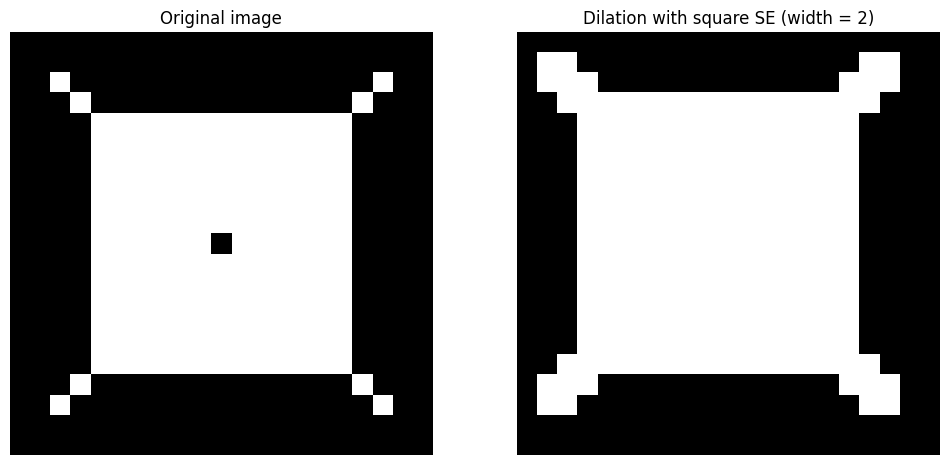

In [1]:
# Dilation
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import square
from skimage.morphology import binary_dilation, binary_erosion, binary_opening, binary_closing

img = np.zeros([21,21],dtype=np.uint8)
img[4:17, 4:17] = 255
img[2,2] = 255
img[18,18] = 255
img[2,18] = 255
img[18,2] = 255
img[3,3] = 255
img[17,17] = 255
img[3,17] = 255
img[17,3] = 255
img[10,10] = 0

se1 = square(2)
dilation_output = binary_dilation(img, se1)

plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray');
plt.title('Original image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(dilation_output, cmap='gray');
plt.title('Dilation with square SE (width = 2)')
plt.axis('off')





## Erosion Operation
Erosion operation, sometimes called Minkowsky subtraction,  shrinks the connected set of pixels with value $p= 1$ of a binary image.

It can be used for
-	reducing the size of the objects in the image and
-	removing the bridges, branches and small protrusions.
	

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/2.png" height=300px><figcaption>Figure 9: Sample  images (left) and their eroded forms (right).</figcaption></p></figure>

Mathematically,   [ **erosion**](https://en.wikipedia.org/wiki/Mathematical_morphology#Erosion) of a binary image, $A$, by structuring element $B$ is defined as,

$$\begin{aligned}A\ominus B &= \{z: (\check B)_z \subseteq A \} = \{ a: a+b\in A, \forall b \in B\}. \end{aligned}$$

Let us explain the above definitions of erosion in more detail.



> **First Equation:** The erosion of an image $A$ by a structuring element $B$ is the set of all points $z =(z_1,z_2)$ such that the reflected structuring element $ (\check B)_z$, translated by $z$, is fully contained in $A$.

> **Second Equation:** The structuring element is swept over the image. At each position where every 1-pixel of the structuring element covers a 1-pixel of the binary image, the binary image pixel corresponding to the origin of the structuring element is $ORed$  with the output image.

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/erosion.gif" height=400px><figcaption>Figure 10: Erosion of the image in the left, by a 3x3 structuring element, according to the first explaination. </figcaption></p></figure>

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/erosion2.gif" height=400px><figcaption>Figure 11: Erosion of the image in the left, by a 3x3 structuring element, according to the second explaination.</figcaption></p></figure>

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/erosion3.gif" height=400px><figcaption>Figure 12: Erosion of a binary image where the black pixels correspond to the object. Circular structuring elements of three different sizes,  shown in the right,  are used to break the bridges and to trim the image. </figcaption></p></figure>

**Example:** Consider an image with a square object of size dxd.

a) If we erode the object by a square structuring element of size (d/4)x(d/4), what is the shape and size of the eroded image?

b) If we erode the object by a rectangular structuring element of size (d/4)x(d), what is the shape and size of the eroded image?

**Answer:** a) The eroded image is another square of size (3d/4)x(3d/4), as shown in Figure 13.c.

b) The eroded image is a line  of length 3d/4, as shown in Figure 13.e.


 <figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image21.png" height=500px><figcaption>Figure 13:  (a) Set $A$. (b) Square structuring element. (c ) Erosion of $A$ by $B$, shown shaded. (d) Elongated structuring element. (e) Erosion of $A$ using the elongated structuring  element. (Adapted from Gonzales and Woods)</figcaption></p></figure>

 **Note:** In both part of the above example, the square object is shrinked. The size and shape of the structuring elements defines the degree of shrinkage, while it reshapes the original object.


**Example:  Shape Filter:** Suppose that we are given an image of white squares with  sizes,  1,3,5,7,9, and 15 wide pixels, as shown in Figure 14.a. Develeop an algoritm to remove all the squares smaller than size 15x15 pixels.

**Answer:**

Step 1: Erode the image by a square structuring element of size 13x13 (see; Figure 14.b)

Step 2: Dilate the output of Step 1 by a structuring element of size 13x13 (see; Figure 14.c).

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image25.png" height=250px><figcaption>Figure 14: (a) Image of white squares of size 1,3,5,7,9, and 15 pixels. (b) Erosion of (a) with a square structuring element of 1's, 13 pixels. (c ) Dilation of (b) with the same structuring element. (Adapted from Gonzales and Woods)</figcaption></p></figure>

Dilation and Erosion are two basic morphological operations, widely used in many application areas of image processing. It is possible to combine these operations with a variety of structurion elements in a sequence, for creating composite morphological operations. Two such widely used operations are **opening** and **closing**, as described in the following subsections.


**Programming exercises:**

1.   Run the following code to see the output of eroding the image with a square structuring element.
2.   Change the width of the structuring element to 3. How does the output change?
3.   Try different structuring elements (e.g. diamond).

NameError: name 'erosion_output1' is not defined

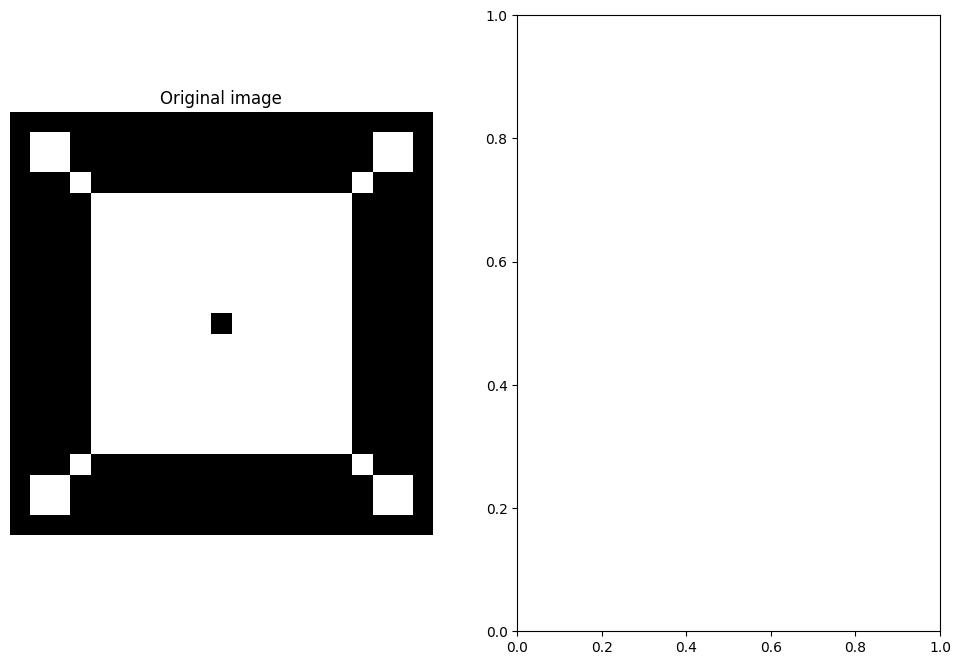

In [2]:
# Erosion
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import square
from skimage.morphology import binary_erosion

img = np.zeros([21,21],dtype=np.uint8)
img[4:17, 4:17] = 255
img[1:3, 1:3] = 255
img[18,18] = 255
img[18:20,18:20] = 255
img[1:3,18:20] = 255
img[18:20,1:3] = 255
img[3,3] = 255
img[17,17] = 255
img[3,17] = 255
img[17,3] = 255
img[10,10] = 0

se1 = square(2)

erosion_output = binary_erosion(img, se1)

plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray');
plt.title('Original image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(erosion_output1, cmap='gray');
plt.title('Erosion with square SE (width = 2)')
plt.axis('off')


## Opening Operation

 [**Opening**](https://en.wikipedia.org/wiki/Mathematical_morphology#Opening) of binary image, $A$, by structuring element, $B$, applies erosion and dilation operation sequentially to the image. Mathematically speaking, it is  defined as,

$$A\circ B = (A \ominus B) \oplus B.$$

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image27.png" height=250px><figcaption>Figure 15: (a)  A circular structuring element $B$ "rolling" along the inner boundary of $A$ for erosion. The smaller dashed triangle indicates the eroded object (the dot indicates the origin of $B$) (c) The eroded object is dilated by the same structuring element. The heavy line is the outer boundary of the opening. (d) Complete opening (shaded). (Adapted from Gonzales and Woods)</figcaption></p></figure>


As we observe in Figure 15, opening operation does not shrink the object, but prunes the sharp corners, depending on the size and shape of the structuring element. When the structuring element has a circular shape, the sharp cornes of the triangle is smoothed. As we increase the diameter of the structuring element, the triangle object shape approaches to a circle.

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/3.png" height=450px><figcaption>Figure 16: Opening of the image $A$ by a 3x3 square shape structuring element.</figcaption></p></figure>

Similarly, opening the noisy rectangle object of Figure 18 with a 3x3 square structuring element prunes the noise  to recover the regtangle.

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/opening.gif" height=400px><figcaption>Figure 17: Opening of an image by three different size circular structuring element, where the seed pixel is at the center. </figcaption></p></figure>

Finally, opening the image of Figure: 17 with a circular structuring element of different size, decompose the image into smaller objects, such as horse, man, bull etc. by breaking the small connections, called bridges. It also removes some small undesired parts, such as the date in the upper left corner.

In summary, opening  trims the sharp corners, prunes the extensions, breaks the bridges and remove the small objects, which may correspond to noise. 


**Programming exercises:**

1.   Run the following code to see the output of opening the image with a square structuring element.
2.   Change the width of the structuring element to 3. How does the output change?
3.   Try different structuring elements (e.g. diamond).

(-0.5, 20.5, 20.5, -0.5)

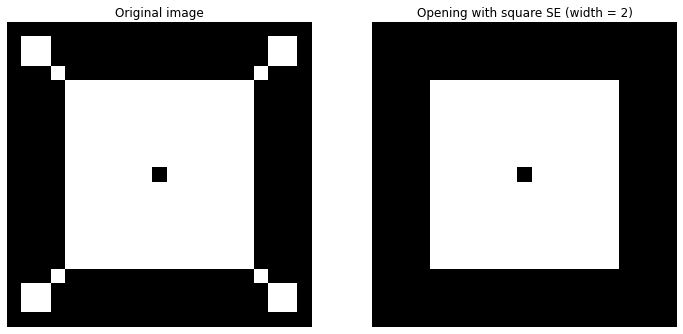

In [ ]:
# Opening
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import square
from skimage.morphology import binary_opening

img = np.zeros([21,21],dtype=np.uint8)
img[4:17, 4:17] = 255
img[1:3, 1:3] = 255
img[18,18] = 255
img[18:20,18:20] = 255
img[1:3,18:20] = 255
img[18:20,1:3] = 255
img[3,3] = 255
img[17,17] = 255
img[3,17] = 255
img[17,3] = 255
img[10,10] = 0

se1 = square(2)

opening_output = binary_opening(img, se1)

plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray');
plt.title('Original image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(opening_output, cmap='gray');
plt.title('Opening with square SE (width = 2)')
plt.axis('off')


## Closing Operation
[**Closing**](https://en.wikipedia.org/wiki/Mathematical_morphology#Closing) of binary image $A$ by structuring element $B$ reverses the erosion and dilation operation of the opening operation. Mathematically, it is   defined as,

$$A\bullet B = (A \oplus B) \ominus  B.$$

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image33.png" height=200px><figcaption>

Figure 18: (a)  A circular structuring element, $B$, "rolling" on the outer boundary of $A$. (b) Heavy line is the outer boundary of the closing. (c ) Complete closing (shaded). (Adapted from Gonzales and Woods)</figcaption></p></figure>

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/4.png" height=400px><figcaption>

Figure 19: Closing the binary image $A$ by a 3x3 structuring element. </figcaption></p></figure>

**Example:** Given the object of shape in Figure 20.a,

a) Develop an algorithm using morphological operations to remove the bridge between two objects and the extensions in the right object.

b) Develop an algorithm using morphological operations to fill up the bays.

**Answer:** a) Removing the bridge and the extensions:

Step 1: Select a circular structuring element, $B$, slightly larger then the width of the bridge.

Step 2: Erode the image by the circular structuring element, $B$ (Figure 20. b and c).

Step 3: Dilate the output of step 2 by the same structuring element (Figure 20. d and e).

b) Filling up the bay in the left hand side:

Step 1: Select the same structuring element, $B$, as in part a.

Step 2: Dilate the image by the circular structuring element, $B$ (Figure 20. f and g).

Step 3: Erode the output of step 2 by the same structuring element (Figure 20. h and i).



<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image79.png" height=550px><figcaption>Figure 20: Morphological opening and closing. The structuring element is the small circle shown in various positions in (b) The dark dot is the center of the structuring element (Adapted from Gonzales and Woods).</figcaption></p></figure>

**Programming exercises:**

1.   Run the following code to see the output of closing the image with a square structuring element.
2.   Change the width of the structuring element to 3. How does the output change?
3.   Try different structuring elements (e.g. diamond).

(-0.5, 20.5, 20.5, -0.5)

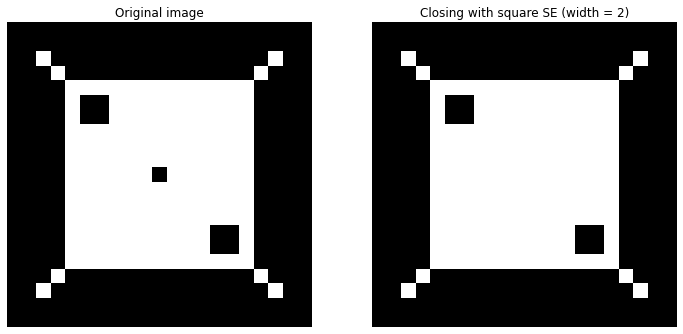

In [ ]:
# Closing 
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import square
from skimage.morphology import binary_closing

img = np.zeros([21,21],dtype=np.uint8)
img[4:17, 4:17] = 255
img[2,2] = 255
img[18,18] = 255
img[2,18] = 255
img[18,2] = 255
img[3,3] = 255
img[17,17] = 255
img[3,17] = 255
img[17,3] = 255
img[5:7,5:7] = 0
img[10,10] = 0
img[14:16,14:16] = 0

se1 = square(2)

closing_output = binary_closing(img, se1)

plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray');
plt.title('Original image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(closing_output, cmap='gray');
plt.title('Closing with square SE (width = 2)')
plt.axis('off')


## Properties of Morphological Operations

- As in the arithmetic addition,   Minkowsky addition (dilation) is commutative and associative. Formally speaking,

$$A\oplus B = B\oplus A$$
and 
$$(A\oplus B)\oplus C = A\oplus (B\oplus C)$$
Minkowsky subtraction (erosion) is neither commutative nor associative. However, it has the following nice property;

$$(A\ominus B)\ominus C=A\ominus (B\oplus C).$$


-	Dilation and erosion are duals of each other with respect to set complementation and reflection, i.e., $$(A\ominus B)^c = A^c \oplus \check{B}.$$
-	Opening and closing are duals of each other with respect to set complementation and reflection, i.e., $$(A\bullet B)^c = A^c \circ \check{B}.$$
-	Opening satisfies the following properties:
	-	$A\circ B$ is a subset of $A$.
	-	if $C$ is a subset of $D$, then $C\circ B$ is a subset of $D\circ B$.
	-	$(A\circ B)\circ B=A\circ B$
-	Closing satisfies the following properties:
	-	$A$ is a subset of $A\bullet B$.
	-	if $C$ is a subset of $D$, then $C\bullet B$ is a subset of $D\bullet B$.
	-	$(A\bullet B)\bullet B=A\bullet B$


##  Image Processing Techniques using Binary Morphological Operations

In the previous chapters, we have seen several image processing techniques  for smoothing an image, detecting the edges and boundaries, increasing the contrast, thresholding etc. Now, we explore the power of the morphological operation for Image Processing.

### Boundary Extraction with Morphological Operations

The **boundary** of a set $A$ can be obtained by first eroding an image, $A$ by a structuring element, $B$, then, performing the set difference between $A$ and its erosion, i.e., 

$$\beta(A) = A - (A\ominus B),$$
where $B$ is a 3x3 structuring element, shown in Figure 21.

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image80.png" height=250px><figcaption>

Figure 21: (a) Set $A$. (b) Structuring element $B$. (c ) $A$ eroded by $B$. (d) Boundary, $\beta(A)$, given by the set difference between $A$ and its erosion. (Adapted from Gonzales and Woods)</figcaption></p></figure>

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image38.png" height=250px><figcaption>

Figure 22: (a) A simple binary image, with 1s represented in white. (b) Result of using boundary equation with a structuring element(Adapted from Gonzales and Woods)</figcaption></p></figure>



### Conditional Dilation

Suppose that we need to keep some shapes, while we dilate an image  $A$ by a structuring element $B$. In order to achieve this goal, we define a conditioning structuring element $C$ and AND the image $A$ by $C$, as we dilate it by B, iteratively. 


Mathematically speaking, let $A_0=A$ and $$A_n = (A_{n-1}\oplus B)\cap C,$$ the **conditional dilation** of $A$ by $B$ with respect to $C$ is defined as, 

$$A_m = A\oplus_{/C} B,$$

where the index $m$ is the smallest index satisfying $A_m=A_{m-1}.$


Conditional dilation

-	removes the components that do not satisfy certain shape and size constraints,
-	leaves a few 1-pixels of those components that do satisfy the constraints,
conditional dilation recovers the latter components using what remains of them after erosion.


### Region Filling for Object Counting

Given a binary image, represented by a point  set $A$, containing the boundary points of a region and a point $p$ inside the boundary, the following procedure **fills the region** with 1's: $$X_k=(X_{k-1}\oplus B)\cap A^c, k=1,2,3,\ldots$$ where $X_0 = p$ and $B$ is a cross-shaped structuring element. The procedure terminates at iteration  $k$ if $X_k=X_{k-1}.$


The set union of $X_k$ and $A$ contains the filled set and its boundary (see:Figure 23).

	
<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image41.png" height=550px><figcaption>Figure 23: Region filling. (a) Set $A$. (b) Complement of $A$. (c ) Structuring element $B$. (d) Initial point inside the boundary. (e)-(h) Various steps of region filling. (i) Final result [union of (a) and (h)]. (Adapted from Gonzales and Woods)</figcaption></p></figure>


Region filling technique is widely used for object counting systems, when the objects have holes, as shown in Figure 24.
<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image42.png" height=250px><figcaption>Figure 24: (a) Binary image (the white dot inside one of the regions is the starting point for the region filling algorithm). (b) Result of filling that region (c ) Result of filling all regions. (Adapted from Gonzales and Woods)</figcaption></p></figure>


### Hit-or-miss Transform for Object Detection

Suppose that we need to detect an object of a prescribed size and shape. We define a composite structuring element, $W,X$, which consists of the object of interest, $X$ surrounded by its local background, $W$, as shown in Figure 25. Let $B=(B_1,B_2)$ denote the set composed of an object and its local background where $B_1$ is the set formed from elements of $B$ associated with the object and $B_2$ is the set of elements of $B$ associated with the background.
**Hit-or-miss transform** is defined by 

$$A\circledast X = (A\ominus X)\cap (A^c \ominus (W-X)).$$

The set $A\circledast X$ contains the origin points at which simultaneously, $X$ found a match (hit) in $A$ and $W$ found a match in $A^c$.

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image44.png" height=550px><figcaption>

Figure 25: (a) Set $A$. (b) A window, $W$ which covers the local background of $X$ and the composite structuring element, ($W-X$) (c ) Complement of $A$. (d) Erosion of $A$ by $X$. (e) Erosion of $A^c$ by $(W-X)$.  (f) Intersection of (d) and (e) the location of the origin of $X$, as desired. (Adapted from Gonzales and Woods)</figcaption></p></figure>	


### Finding the Skeleton 

Skeleton of an object is defined as the set of connected pixels,  which are equidistant to its boundaries (See Figure 42). Skeleton of an object can be obtained by finding the centers of the maximum disk touching to the boundary pixels of the object.

The above definition of skeleton enables us to represent the skeleton in terms of the morphological operations. 


<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image85.png" height=350px><figcaption>

Figure 26: (a) Set $A$. (b) Various positions of maximum disks with centers on the skeleton of $A$. (c ) Another maximum disk on a different segment of the skeleton of $A$. (d) Complete skeleton. (Adapted from Gonzales and Woods) </figcaption></p></figure>

Mathematically speaking, the skeleton of an object is defined as,
$$S(A) =\cup_{k=0}^K S_k(A),$$
where  
$$S_k(A) =(A\ominus B)_k- (A\ominus B)_k \circ B,$$

and $K$ is the  iteration number, which outputs one pixel wide skeleton.

In the above equation $(A\ominus B)_k$ shows the erosion of $A$ by a small structuring element, $B$,  which successively erodes the set $A$, $k$ times:
$$(A\ominus B)_k = (A \ominus \underbrace{B)\ominus B ....\ominus B}_{k \quad times}.$$





## Thinning
Thinning operation is a little different from finding the skeleton. Instead of finding the set of connected equidistant points from the boundary, thinning operation peals the boundary pixels iteratively, until the smallest set of connected  pixels remain.

Thinning of a binary image, $A$, can be defined by an iterative hit-or-miss transform. At each iteration, a structuring element $B_k$ is defined by rotating an initial structuring element, $B$, as shown in Figure 29.a. Iterations halt when the resulting set consists of the smallest connected component, called the thinned image.

Mathematicaly speaking, at iteration $k$ thinning operation performs the following operation: 

$$\begin{aligned} A\otimes B_k &= A-(A\circledast B_k) \\ &= A\cap (A\circledast B_k)^c.\end{aligned}$$

where $B_k$ is the rotated version of $B_{k-1}.$ 



<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image47.png" height=550px><figcaption>

Figure 27: (a) Sequence of rotated structuring elements used for thinning. (b) Set $A$. (c ) Result of thinning with the first element. (d)-(i) Results of thinning with the next seven elements (there was no change between the seventh and eighth elements). (j) Result of using the first element again (there were no changes for the next two elements). (k) Result after convergence. (l) Conversion to $m$-connectivity. (Adapted from Gonzales and Woods)</figcaption></p></figure>

**Programming exercises:**

1.   Run the following code to see the output of thinning and skeletonization.

(Text(0.5, 1.0, 'Partial Thinning'), (-0.5, 700.5, 676.5, -0.5))

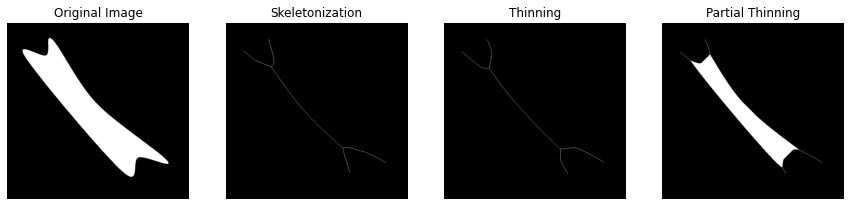

In [ ]:
# Skeletonization and Thinning
from skimage.morphology import skeletonize, thin
from skimage import img_as_float
from skimage import io
from skimage.color import rgb2gray
import numpy as np

!wget -cq https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/skeleton_image.jpg

image = io.imread('skeleton_image.jpg')
image = img_as_float(np.round(rgb2gray(image)))

skeleton = skeletonize(image)
thinned = thin(image)
partial_thinned = thin(image, max_iter = 30)

plt.figure(figsize=(15,8))
plt.subplot(141), plt.imshow(image, cmap='gray'), 
plt.title('Original Image'), plt.axis('off')
plt.subplot(142), plt.imshow(skeleton, cmap='gray'), 
plt.title('Skeletonization'), plt.axis('off')
plt.subplot(143), plt.imshow(thinned, cmap='gray'),  
plt.title('Thinning'), plt.axis('off')
plt.subplot(144), plt.imshow(partial_thinned, cmap='gray'),  
plt.title('Partial Thinning'), plt.axis('off')


### Thickening

**Thickening** is the morphological dual of thinning. An iterative process defined below is applied to the thinned image, at $k$th itearation, as follows;

 $$A\odot B_k = A\cup(A\circledast B_k),$$ 
 
where $B_k$ is the same  structuring element applied  for thickening, but with all 1's and 0's interchanged.


<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image49.png" height=350px><figcaption>

Figure 28: (a) Set $A$. (b) Complement of $A$ (c ) Result of thinning the complement of $A$. (d) Thickened set obtained by complementing (c ). (e) Final result, with no disconnected points. (Adapted from Gonzales and Woods)</figcaption></p></figure>	

Table 1 provides a list for popular morphological operations used in Binary Image Analysis.

|Operation|Equation|Comments <br> (The roman numerals refer to the <br>structuring elements shown in Figure 43).|
|--|--|--|
|Translation| $(A)_z=\{w:w=a+z,\text{ for }a\in A\}$ | Translates the origin of $A$ to point $z$.
| Reflection|$\check{B}=\{w:w=-b, \text{ for }b\in B\}$ | Reflects all elements of $B$ about the origin of this set.|
| Complement|$A^c=\{w:w\notin A \}$ | Set of points not in $A$|
|Difference |$\begin{aligned}A-B&=\{w:w\in A, w\notin B\}\\ &=A\cap B^c\end{aligned}$ | Set of points that belong to $A$ but not to $B$|
|Dilation |$A\oplus B = \{z:(\check{B})_z \cap A \neq\emptyset\}$ | "Expands" the boundary of $A$. ($\text{I)}$|
|Erosion | $A\ominus B=\{z:(B)_z\subseteq A \}$|"Contracts" the boundary of $A$. ($\text{I)}$ |
|Opening |$A\circ B = (A\ominus B) \oplus B$ | Smoothes contours, breaks narrow isthmuses, and eliminates small islands and sharp peaks. ($\text{I)}$ |
|Closing | $A\bullet B = (A\oplus B) \ominus B$| Smoothes contours, fuses narrow breaks and long thin gulfs, and eliminates small holes. ($\text{I)}$|
|Hit-or-miss <br> transform | $\begin{aligned}A\circledast B &= (A\ominus B_1)\cap (A^c \ominus B_2)\\ &=(A\ominus B_1)- (A^c \ominus \hat{B_2})\end{aligned}$| The set of points (coordinates) at which, simultaneously, $B_1$ found a match ("hit") in $A$ and $B_2$ found a match in $A^c$|
|Boundary <br> extraction |$\beta(A) = A - (A\ominus B)$ |Set of points on the boundary of set $A$. ($\text{I}$) |
|Region <br> filling |$X_k=(X_{k-1}\oplus B)\cap A^c$;<br>$X_0=p$ and <br> $k=1,2,3,\ldots$ |Fills a region in $A$, given a point $p$ in the region. ($\text{II}$) |
|Connected <br>Components |$X_k=(X_{k-1}\oplus B)\cap A$;<br>$X_0=p$ and <br> $k=1,2,3,\ldots$ | Finds a connected component $Y$ in $A$, given a point $p$ in $Y$. ($\text{I}$)|
|Convex hull | $X_k^i=(X_{k-1}^i\circledast B^i)\cup A$;<br>$i=1,2,3,4$;<br>$k=1,2,3,\ldots$;<br>$X_0^i=A$; and <br> $D^i=X_{conv}^i$. |Finds the convex hull $C(A)$ of set $A$, where "conv" indicates convergence in the sense that $X_{k}^{i}=X_{k-1}^{i}$. ($\text{III}$) |
|Thinning |$\begin{aligned} A\otimes B &= A-(A\circledast B) \\ &= A\cap (A\circledast B)^c\end{aligned}$ <br> $A\otimes\{B\} = ((\ldots((A\otimes B^1)\otimes B^2)\ldots)\otimes B^n)$ <br> $\{B\}=\{B^1,B^2, B^3,\ldots,B^n\}$|Thins set $A$. The first two equations give the basic definition of thinning. The last two equations denote thinning by a sequence of structuring elements. This method is normally used in practice. ($\text{IV}$) |
|Thickening |$A\odot B = A\cup(A\circledast B)$ <br> $A\odot \{B\} = ((\ldots(A\odot B^1)\odot B^2\ldots)\odot B^n)$  |Thickens set $A$. (See preceeding comments on sequences of structuring elements). Uses $\text{IV}$ with 0's and 1's reversed. |
|Skeletons|$S(A)=\bigcup_{k=0}S_k(A)$ <br> $S_k(A) = \bigcup_{k=0}^{K}\{(A\ominus kB)-[(A\ominus kB)\circ B]\}$ <br> Reconstruction of $A$; <br> $A=\bigcup_{k=0}^{K}(S_k(A)\oplus kB)$ |Finds the skeleton $S(A)$ of set $A$. The last equation indicates that $A$ can be reconstructed from its skeleton subsets $S_k(A)$. In all three equations, $K$ is the value of the iterative step after which the set $A$ erodes to the empty set. tThe notation $(A\ominus kB)$ denotes the $k$th iteration of successive erosion of $A$ by $B$. ($\text{I}$) |
|Pruning| $X_1=A\otimes\{B\}$<br> $X_2=\bigcup_{k=1}^{8}(X_1\circledast B^k)$ <br> $X_3=(X_2\oplus H)\cap A$ <br> $X_4=X_1\cup X_3$| $X_4$ is the result of pruning set $A$. The number of times that the first equation is applied to obtain $X_1$ must be specified. Structuring elements $\text{V}$ are used for the first two equations. In the third equation $H$ denotes structuring element $\text{I}$. |

Table 1: List of Morphological operations for binary Image Analysis


## Morphological Operations for Gray Scale Images

How can we extent the basic morphological operations for gray scale or multispectral images?

A  simple answer to this question may be to binarize a gray scale image by some histogram thresholding methods, then, apply the binary dilation and erosion. In some practical applications, such as document image analysis, this method work very efficiently. When the object of interest, such as letters of a document, can be easily extracted by a simple thresholding method, we can binarize the document and apply the binary erosion and dilation to enhance the shape of the letters. However, in many images this may not be the case, where we need to redefine  morphological operations. 

In order to extent the morphological operations to gray scale images, we make an analogy from topographic maps, as shown in Figure 29.


<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/topography.png" height=450px><figcaption> Figure 29: Topographic map of an terrain.   </figcaption></p></figure>

The discrete function, $f(x,y)$, representing a  2-dimensional color or gray scale image can be considered as a topographic map, where the basin of the map corresponds to the domain, $(x,y)\in D$  and the hight of the map at each basin coordinate, $(x,y)$, represent the range, $r\in R$, which corresponds to gray value, $f(x,y) = r$. In this analogy, gray scale erosion and dilation of an image can be formulated as increasing and decreasing the hight of the topographic map at each point to produce a desired output. Thus, the two-dimensional  image function is reshaped by   gray scale morphological operations, using a gray scale  structuring function,  as if we reshape the mountains and valleys of the topographic map. 

Let us formalize the above analogy of reshaping a topographic map by gray scale morphology. This time, representation of a gray scale image by a point set is equivalent to  representing it by  a two dimensional function. Then, the application of  set operation to the topographic maps corresponds to adding and/or subtracting the image functions, as explained in the following section..





### Gray Scale Dilation

Suppose that, we represent a two dimensional gray scale image by a function,  $f(x,y),$ and a structuring element as another two dimensional function, $k(x,y)$ . In practice, the size of the structuring function is much smaller than that of the image function.

Gray scale dilation operation translates a  structuring function, $k(x,y)$,  on an  image function, $f(x,y),$ as if we move a car on a topographic map. In other words, the  origin of the structuring element is translated over the top surface of the image function. As we translate the origin of the structuring function, we add the gray values of all the overlapping pixels of the image and that of the structuring element function. We select the maximum of all the additions to assign the gray value of the image pixel under the seed pixel of the structuring function.  

Figure 30.a, b shows a one dimensional image, $f(x)$ and a structuring function, $k(x)$. We translate $k(x)$ over top surface of one dimensional image of triangle and assign the  maximum of $[(f(x+s)+ k(s)]$  to the origin of the structuring element  to obtain the dilated image of triangle (see Figure 30.c, d).



<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image92.png" height=450px><figcaption>

Figure 29: (a) A simple one-dimensional image function, $f(x)$. (b) A one-dimensional structuring element of constant height $A$. (c ) Result of dilation for various positions of sliding $b$ past $f$. (d) Complete result of dilation (shown solid). (Adapted from Gonzales and Woods) </figcaption></p></figure>

Mathematically speaking, the gray scale dilation is defined as;

$$f(x,y)\oplus_g k(x,y) = \max_{(s,t)\in D_k}\{f(x+s,y+t)+k(s,t)\}.$$



The above definition of  gray scale dilation assigns to each seed pixel location, the maximum value found over the neighborhood of the
structuring function. The dilated value of a pixel
at location $(x,y)$ is the maximum
value of $[f(x+s,y+t)+k(s,t)]$ in the domain of the structuring function, when its origin is at
$(x,y).$

Note that the gray scale dilation increases the hight of the corresponding topographic map, depending on the gray levels and size of the structuring  function and it results in lighter colors in the image.



### Gray Scale Erosion

As in the gray scale dilation, gray scale erosion  translates a  structuring function, $k(x,y)$,  on an  image function, $f(x,y),$ as if we move a car on a a topographic map. This time, we subtract the gray values of  the overlaping pixels of the  structuring function from that of the image  function and select the minimum of all the subtractions, as we translate the origin of the structuring function over the image.  

Figure 31 shows the erosion of a one dimensional image, $f(x)$ and a structuring function, $k(x)$ of Figure 29.a and b. We translate $k(x)$ over top surface of one dimensional image of triangle and assign the  minimum of $[(f(x+s)- k(s)]$  to the origin of the structuring element  to obtain the dilated image of triangle. 

Mathematically, the gray scale erosion is defined as;

$$f(x,y)\ominus_g k(x,y) = \min_{(s,t)\in D_k}\{f(x+s,y+t)-k(s,t)\}.$$

The above definition of  gray scale erosion assigns to each seed pixel, the minimum value
found over the neighborhood of the
structuring function. The eroded value of a pixel
at location $(x,y)$ is the minimum
value of $[f(x+s,y+t)-k(s,t)]$ in the domain of the structuring function, when its origin is at
$(x,y).$

**Note:** Gray scale erosion decreases the hight of the corresponding topographic map, depending on the gray levels and size of the structuring  function and it results in darker colors in the image.




<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image93.png" height=250px><figcaption>Figure 30: Erosion of the function shown in Figure 29(a), by the structuring element shown in Figure 30(b). (Adapted from Gonzales and Woods) </figcaption></p></figure>

The output of dilation and erosion and dilation of an image with a uniform structuring function is shown in Figure 32. Note that the arithmetic additions and subtranctions are mode operations to keep the gray values in the interval, $[0, (2^k-1)]$  for an image of $2^k$ gray levels.

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image94.png" height=350px><figcaption>Figure 31: (a) Original image. (b) Result of dilation. (c ) Result of erosion. (Courtesy of Mr. A. Morris, Leica Cambridge, Ltd.) (Adapted from Gonzales and Woods) </figcaption></p></figure>

**Note:** When the structuring element is uniform with a constant hight, 
$$k(x,y) =C, \quad \forall (x,y)\in D_k,$$ 
gray scale dilation and erosion ligthens or darkens the image with the same amount, proportional to the height, $C$, of the structuring function.



### Gray Scale Opening and Closing 

Gray scale opening and closing are  trivial extensions of binary opening and closing, where we replace the binary operations by their gray scale counterparts. 

Mathematically, gray scale opening is defined as,

$$f(x,y)\circ_g k(x,y) = f(x,y)\ominus_g k(x,y)\oplus_g k(x,y),$$
whereas gray scale closing is defined as,

$$f(x,y)\bullet_g k(x,y) = f(x,y)\oplus_g k(x,y)\ominus_g k(x,y).$$

**Motivating Question:** What happens to an image, when we apply gray scale opening or closing?

Let us remember the topological map analogy. When we apply a gray scale opening to an image with a structuring function of circular cross section, opening corresponds to rolling a ball under the map. When the ball does not fit in the sharp peaks of the map, it trims the corresponding colors, resulting in darkening very light colors of the hills. When the ball fits into the hills, opening keeps these colors. This fact is depicted in Figure 33. a, b, c, where a one dimensional image is opened by a circular structuring function.

Similarly, when we apply a gray scale closing to an image with a structuring function of circular cross section, closing corresponds to rolling a boll over  the map surface. When the ball does not fit into the valleys of the map, it it fills up these valleys, resulting in lightening the dark colors. When the ball fits into the valleys, closing keeps these dark colors. This fact is depicted in Figure 33. d, e, f, where a one dimensional image is closed by a circular structuring function.

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image95.png" height=400px><figcaption>Figure 32: (a) A gray-scale scan line. (b) Positions of rolling ball for opening. (c) Result of opening. (d) Positions of rolling ball for closing. (e) Result of closing. (Adapted from Gonzales and Woods) </figcaption></p></figure>



The effect of gray scale opening and closing can be observed from Figure 33. Note that gray scale opening darkens the background, whereas the closing operation smooths the horse collar.


<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image96.png" height=250px><figcaption>Figure 33: (a) Opening and (b) closing of Figure 31(a). (Courtesy of Mr. A. Morris, Leica Cambridge, Ltd.) (Adapted from Gonzales and Woods) </figcaption></p></figure>







##  Image Processing Techniques Using Gray Scale Morphological Operations

Gray scale morphology  can be combined in a variety of sequences by employing several structuring functions to produce morphological algorithms for smoothing, finding the gradient image, segmentation, object detection etc.  

Recall that the basic operations of  gray-scale dilation and erosion are the maximum and minimum operations, taken over the domain of the structuring function. Thus, structuring functions can be considered as the nonlinear filters of gray scale morphology.



### Morphological smoothing

The  basic morphological smoothing is a gray level
opening followed by a gray level closing operation. Methematically, smoothing operation is defined as;

$$S(f(x,y)) = (f(x,y)\circ_g k(x,y))\bullet_g k(x,y),$$

where $k(x,y) = C, \forall (x,y)\in D_k,$ is a uniform and small filter.

The above operation removes both bright and dark artifacts of noise.



<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image97.png" height=250px><figcaption>

Figure 34: Morphological smoothing of the image in Figure 31(a). (Courtesy of Mr. A. Morris, Leica Cambridge, Ltd.) (Adapted from Gonzales and Woods) </figcaption></p></figure>	





### Morphological Gradient

In the previous chapters, we have seen several gradient (first derivative) filters, where the edges of an image can be successfully extracted using the convolution operation.  Similarly, we can define morphological gradient for edge detection. Mathematically, morphological gradient is defined as,

$$\nabla f(x,y) = (f(x,y)\oplus_g k(x,y)) - (f(x,y)\ominus_g k(x,y)),$$

where $k(x,y) =C, \forall (x,y)\in D_k$ is a small structuring function. The size and height, $C$, of the structuring function defines the type of the edges. As we increase the size (domain) and height of the structuring function, we obtain thicker and darker edges.

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image98.png" height=250px><figcaption>Figure 35: Morphological gradient of the image in Figure 32(a). (Courtesy of Mr. A. Morris, Leica Cambridge, Ltd.) (Adapted from Gonzales and Woods) </figcaption></p></figure>


### Top and Bottom-Hat Transformation

Suppose that we have an object on a slightly varying background. How can we segment the object from the background?

Top or buttom-hat transform of a gray scale image can extract peaks or valleys of the image, which usually correspond to the object and background of the image. 

 Mathematically, top-hat transform is defined as,

$$T(f(x,y)) = f(x,y)- (f(x,y)\circ_g k(x,y)).$$

Similarly, bottom-hat transform is defined as,

$$B(f(x,y)) = (f(x,y)\circ_g k(x,y))-f(x,y).$$


<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image99.png" height=250px><figcaption>Figure 36: Result of performing a top-hat transformation on the image in Figure 30(a). (Courtesy of Mr. A. Morris, Leica Cambridge, Ltd.) (Adapted from Gonzales and Woods) </figcaption></p></figure>




**Programming exercises:**

1.   Run the following code to see the output of several morphological operations on the example grayscale image.

(Text(0.5, 1.0, 'Closing'), (-0.5, 20.5, 20.5, -0.5))

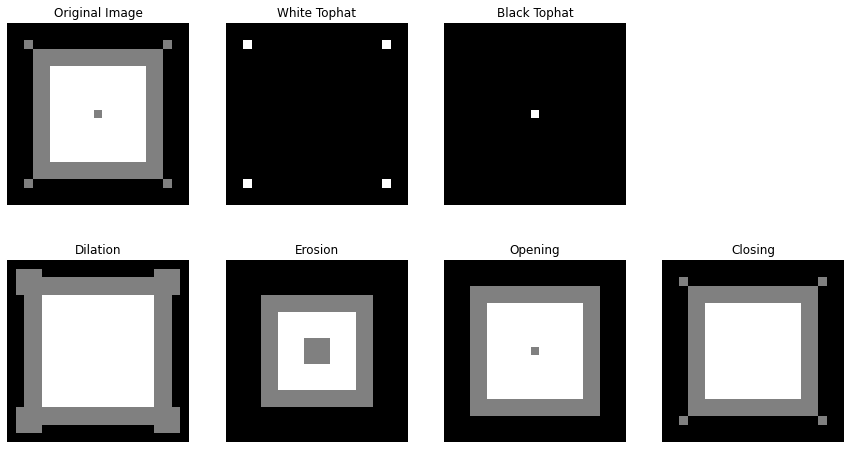

In [ ]:
# Morphological operations on gray scale images
from skimage import img_as_ubyte, data
from skimage.morphology import dilation, erosion, opening, closing, white_tophat, black_tophat

img = np.zeros([21,21],dtype=np.uint8)

img[3:18, 3:18] = 128
img[5:16, 5:16] = 255
img[2,2] = 128
img[10,10] = 128
img[18,18] = 128
img[2,18] = 128
img[18,2] = 128

se = square(3)

white_tophat_output = white_tophat(img, se)
black_tophat_output = black_tophat(img, se)
dilation_output = dilation(img,se)
erosion_output = erosion(img,se)
opening_output = opening(img,se)
closing_output = closing(img,se)

plt.figure(figsize=(15,8))
plt.subplot(241), plt.imshow(img, cmap='gray'), 
plt.title('Original Image'), plt.axis('off')
plt.subplot(242), plt.imshow(white_tophat_output, cmap='gray'), 
plt.title('White Tophat'), plt.axis('off')
plt.subplot(243), plt.imshow(black_tophat_output, cmap='gray'),  
plt.title('Black Tophat'), plt.axis('off')
plt.subplot(245), plt.imshow(dilation_output, cmap='gray'),  
plt.title('Dilation'), plt.axis('off')
plt.subplot(246), plt.imshow(erosion_output, cmap='gray'),  
plt.title('Erosion'), plt.axis('off')
plt.subplot(247), plt.imshow(opening_output, cmap='gray'),  
plt.title('Opening'), plt.axis('off')
plt.subplot(248), plt.imshow(closing_output, cmap='gray'),  
plt.title('Closing'), plt.axis('off')


### Morphological Segmentation

When the object regiona have  some rugular texture such as circles of different size, morphological operations can segment them. 

Consider the image of Figure 38, where two regions have circles of different sizes. If we erode the image with a structuring element, which is slightly larger than the smaller circle and smaller then the biger circles. Then, the dilated image consists of only the region with larger circles.

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image100.png" height=250px><figcaption>Figure 37: (a) Original image. (b) Image showing boundary between regions of different texture. (Courtesy of Mr. A. Morris, Leica Cambridge, Ltd.) (Adapted from Gonzales and Woods) </figcaption></p></figure>

Similarly, the image of Figure 39 has flat regions and circles of arious sizes.  Eroding the image with different sizes of circular structuring elements can easily segment the regions with respect to the texture of the regions.

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image101.png" height=250px><figcaption>Figure 38: (a) Original image consisting of overlapping particles. (b) Size distribution. (Courtesy of Mr. A. Morris, Leica Cambridge, Ltd.) (Adapted from Gonzales and Woods) </figcaption></p></figure>
-------




**Programming exercises:**

1.   Run the following code to perform morphological segmentation.

/usr/local/lib/python3.7/dist-packages/skimage/morphology/_deprecated.py:5: skimage_deprecation: Function ``watershed`` is deprecated and will be removed in version 0.19. Use ``skimage.segmentation.watershed`` instead.
  def watershed(image, markers=None, connectivity=1, offset=None, mask=None,


Text(0.5, 1.0, 'Results of Watershed')

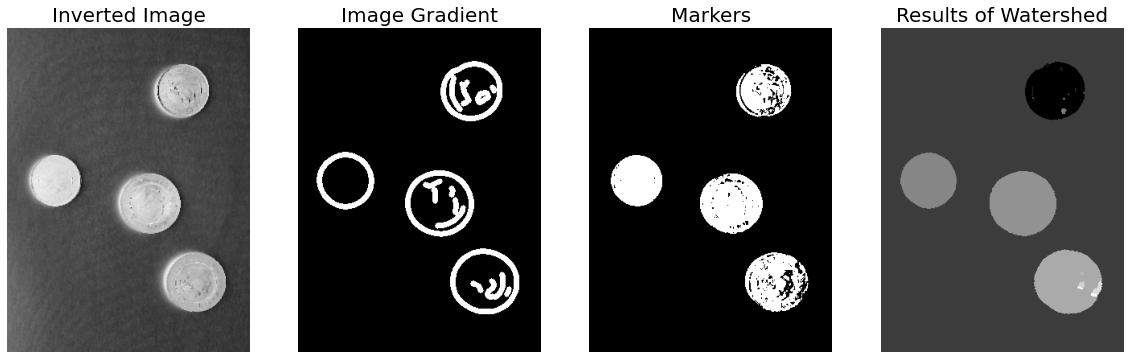

In [ ]:
# Morphological segmentation with Watershed algorithm
from skimage import io, feature, color
from skimage.util import img_as_ubyte
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage.morphology import binary_fill_holes
from skimage.morphology import square, disk
from skimage.filters.rank import median
from skimage.transform import rescale
from skimage.filters import rank
from skimage.filters import sobel
from skimage.morphology import watershed
from skimage.morphology import opening, closing, binary_dilation, dilation, extrema
from skimage.measure import label



!wget -cq https://raw.githubusercontent.com/hazalmogultay/466Images/master/W12/coins.jpeg
im_color = io.imread('coins.jpeg')
im_g = color.rgb2gray(im_color)
im = img_as_ubyte(rescale(im_g, 0.1, anti_aliasing=False))
im = np.invert(im)


# Apply median filter
im = median(im, disk(1))

# Detect edges with Canny edge detector
im_gradient = feature.canny(im, sigma=3,low_threshold=15, high_threshold=20)
# Apply dilation (edges become thicker)
im_gradient = dilation(im_gradient, disk(3))

# Find markers from background and coins
markers = np.zeros_like(im)
markers[im > 160] = 2
markers[im < 20] = 1
label_img2 = label(markers)

# Apply Watershed algorithm on the image gradient using the markers to perform segmentation 
labels1 = watershed(im_gradient, markers = label_img2)

plt.figure(figsize=(20,15))
plt.subplot(141)
plt.imshow(im, cmap='gray')
plt.title('Inverted Image', fontsize=20)
plt.axis('off')

plt.subplot(142)
plt.imshow(im_gradient, cmap='gray') 
plt.title('Image Gradient', fontsize=20)
plt.axis('off')

plt.subplot(143)
plt.imshow(markers.astype('int'), cmap='gray')
plt.title('Markers', fontsize=20)
plt.axis('off')

plt.subplot(144)
plt.imshow(labels1, cmap='gray')
plt.axis('off')
plt.title('Results of Watershed', fontsize=20)

## Popular Application of Morphological Operation in Image Processing

Morphological operations are very powerful tools, which are widely used in many applications of image processing to remove the noise, to enhance image, to detect the edges, to segment the objects etc. In the following sections, we overview few of these applications.

### Application to Document Image Analysis

Morphological operations are widely used in document image analysis to enhance the quality of the text.  For example, dilation operation bridges the broken characters.  Figure 39 shows dilation of a binary text image by a 3x3 structuring element of cross shape.  

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image19.png" height=350px><


Figure 39: (a) Sample text of poor resolution with broken characters (magnified view). (b) Structuring element. (c ) Dilation of (a) with (b). Broken segments were joined (Adapted from Gonzales and Woods).</figcaption></p></figure>

### Application to Fingerprint Recognition

 
Fingerprint recognition is one of the most well known biometrics for personnel identification systems, where  a machine learning algorithm automatically recognizes the person from his/her fingerprint, captured by an optic device.  However, due the external factors, such as dust or pollution, the captured image may contain undesired noises, as shown in Figure 33. In order to remove the noise the image is first binarized. Then, a series of binary morphological operation is applied, as shown in Figure b, c, d, e, f.


<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image34.png" height=500px>

<figcaption>

Figure 40: (a) Noisy fingerprint image. (c ) Eroded image. (d) Opening of $A$. (e) Dilation of the opening. (f) Closing of the opening. (Original image for this example courtesy of the National Institute of Standards and Technology) (Adapted from Gonzales and Woods)</figcaption></p></figure>

### Application to Remote Sensing 

Extracting the man-maid objects, such as buildings, roads, parking lots, airports etc., in a remotely sensed images is a crucial problem. These objects mostly have geometric shapes, such as rectangles, polygons or thick lines. Due to the  weather conditions or the restrictions of the camera parameters the satellite images are corrupted by a heavy noise. As a result,  shape of the man-maid objects  are distorted to some amorphous structures.  Morphological operations are very successful for extracting these type of objects in satellite images. Figure 41 (left) shows a remotely sensed airport image. In order to extract the runways of the airport a series of morphological operation is applied to this image. First the image is binarized by a histogram thresholding method. Then, a series of dilation and erosion operation is applied to remove the residential area to end up with the airport facility only. Finally, the runway is extracted by designing the structuring elements of opening and closing, using the expert information about the length and the width of the runway.

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W1/figure34.png" height=300px><figcaption>

Figure 41: A satellite image (left). The output of an airport facility (middle) and runway(right) detection algorithms.  </figcaption></p></figure>

Morphological image processing is also applicable to detect and count the buildings of various sizes in a satellite image.  As an example,  Figure 29 (left) shows a satellite image of a city area. A building detection algorithm detects and binarizes the image  (Figure 29 (middle)). Then, using the hit and miss operations  with different sizes of structuring element , buildings with various size are detected (Figure 29 (left)).

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image74.png" height=250px><figcaption>

Figure 42: Counting  the buildings in various size and shape in a satellite image. a9 Original image. b) the output of the building detection algorithm. c) Labeling various sizes of buildings.    </figcaption></p></figure>


### Quality Control 

In many manufacturing line, quality control is a very crucial problem. Automating the quality control of the manufactured goods saves a great amount of time and resource. When the  good has a well-defined structure, such as the wiring of a microelectronic circuit, shown in Figure 43, we apply a closing operation to remove the bays in the image. Then we subtract the original image from the closed image to detect the defects of the circuit, indicated by red bays. 

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image58.png" height=250px><figcaption>Figure 43: Detecting defects in a microelectronic circuit. [Link](http://www.mmorph.com/mxmorph/html/mmdemos/mmdlith.html).</figcaption></p></figure>

Another example for quality control is indicated in Figure 44, where the quality of the potatoes are assessed from the skeleton of the shapes. In this case, the potatoes are first binirized. Then, the morphological operations are applied to find the skeleton and the holes corresponding to the skin spots. Finally, the number of branches of in the skeleton is used to grade the quality of the potatoes.

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image62.png" height=250px><figcaption>Figure 44: Grading potato quality by shape and skin spots. [Link](http://www.mmorph.com/mxmorph/html/mmdemos/mmdpotatoes.html).</figcaption></p></figure>

Note that the above example requires domain knowledge to design the morphological operations and the corresponding structuring elements. In the first example of Figure 43, for detecting the defects of a microelectronic circuit, we need to know the thickness and the length of the wires, together with the distance between the them. In the second example of Figure 44, assessing the quality of potatoes requires to design a grading schema based on  the shape and the skin properties of a high-to-low quality potatoes.


### Object Detection and Classification

Morphological operations are very useful for detecting and classification of well-structures objects.

As an example, Figure 45 shows a circuit board with various components. These components can be detected by hit and miss operations with appropriate shape of the structuring element, designed by using the domain knowledge.

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image60.png" height=250px><figcaption>Figure 45: Decomposing a printed circuit board in its main parts. [Link](http://www.mmorph.com/mxmorph/html/mmdemos/mmdpcb.html).</figcaption></p></figure>

A similar type of hit and miss operation can be designed for various types of nails, shown in Figure 46.



<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image64.png" height=250px><figcaption>Figure 46: Classifying two dimensional pieces. [Link](http://www.mmorph.com/mxmorph/html/mmdemos/mmdpieces.html).</figcaption></p></figure>

A successful application  of morphological operations is lane detection on high ways. Figure 47 shows an image captured by an optic camera located on a highway traffic sign. Taking the temporal average of several images removes the moving objects, such as cars, trucks etc. n(Figure 47.b). If we further take the average of difference images, we barely capture the lanes, as shown in Figure 47.c.

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image68.png" height=250px><figcaption>Figure 47: Lane detection example. (a) Traffic scene. (b) Temporal average. (c ) Average of differences. (Adapted from CMM/ENSMP/ARMINES)</figcaption></p></figure>

In order to detect the exact location of the lanes, we binarize the image of Figure 47.c. and dilate the binarized image.  Then, we use top hat transformation to detect the lines, between the lanes. Finally, we use the domain information to mark the lanes at each side of the detected line (Figure 48.c).
<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W11/image71.png" height=250px><figcaption>Figure 48: Lane detection example. (a) Threshold and dilation to detect lane markers. (b) White line detection (top hat). (c ) Detected lanes. (Adapted from CMM/ENSMP/ARMINES)</figcaption></p></figure>

Morphological operations are also widely used in  many Computer Vision algorithms as a preprocessing step in object recognition and classification problems.



# Chapter Summary

Can we morph an object in an image into a desired shape? For example, can we shrink or enlarge an object according to a prescribed goal? Can we close the holes in an object? Can we prune the notches, corresponding to noise on the object boundary?

Mathematical morphology, developed by H. Minkowsky,  provides a rigorous tool for reshaping the objects into a desired form in binary and color images, using set theory.  Minkowsky operations are defined based on the the logical operations, such as AND, OR or NOT, defined over the sets 

In this chapter, we first represented binary images by point sets, where the elements of the set is defined as  the pixel coordinates, which belong to an object. Then, we introduced two new operations for image processing, namely, Minkowsky addition (dilation) and Minkowsky subtraction (erosion). Structuring element is a small image patch, which is designed for reshaping the objects of an image. Dilation inflates an object, whereas erosion shrinks it, depending of the shape of the structuring element. Based upon the dilation and erosion, it is possible to define a set of morphological operations for reshaping  an object into another form. Two widely used morphological operations are the opening and closing operations. While opening trims the undesired extensions on the object boundary, closing fills up the holes and bays without changing the actual size of the object.

Morphological operations can be extended to gray level or color images by assuming an image as a topographical map, where each coordinate is associated with a hight. Then, we represent an image by a point set with the elements corresponding to the pixel coordinates and height of the map corresponding to the color or gray values. We can, then, apply logical operations between two topographic maps of an image function and a structuring function.

Morphological operations are very handy in many image processing applications, such as fingerprint recognition, object detection and counting, image segmentation and quality control.